# Purpose

Predict the customers to make calls to, using features that are not related to the  campaign; only the demographic features ('age', 'job', 'marital', 'education') and financial features ('default', 'balance', 'housing', 'loan') are used.

# Library install

use runtime 2025.07
latest version of pycaret is only supported in python versions up until 3.11

In [ ]:
%pip install pycaret[tuners]

In [ ]:
import pycaret
pycaret.__version__

'3.3.2'

In [ ]:
%pip install hyperopt

In [ ]:
import hyperopt
hyperopt.__version__

'0.2.7'

hyperopt: hyperparam tuning based on bayesian optimization

In [ ]:
%pip install tune-sklearn ray[tune]==2.7

In [ ]:
import random

seed = 2694 #random.randint(1000, 9999)

# Data Import

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/My Drive/Apziva/Project 2 - Term Deposit/term-deposit-marketing-2020.csv'
df = pd.read_csv(data_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
features_without_campaign = df[df.columns.difference(['y', 'contact', 'day', 'month', 'duration', 'campaign'])]
target = df['y']

# Split the data into training and testing sets
X_train_call_recipient, X_test_call_recipient, y_train_call_recipient, y_test_call_recipient = train_test_split(features_without_campaign, target, test_size=0.3, random_state=seed, stratify=target)

# Combine X_train and y_train for PyCaret's setup
df_train_call_recipient = pd.concat([X_train_call_recipient, y_train_call_recipient], axis=1)

In [ ]:
features_without_campaign.head()

,age,balance,default,education,housing,job,loan,marital
0,58,2143,no,tertiary,yes,management,no,married
1,44,29,no,secondary,yes,technician,no,single
2,33,2,no,secondary,yes,entrepreneur,yes,married
3,47,1506,no,unknown,yes,blue-collar,no,married
4,33,1,no,unknown,no,unknown,no,single


In [ ]:
target.head()

,y
0,no
1,no
2,no
3,no
4,no


# Pycaret Model call

## Baseline Models

In [ ]:
from pycaret.classification import *

In [ ]:
pycaret_setup = setup(data = df_train_call_recipient, target = 'y', session_id = seed, test_data = pd.concat([X_test_call_recipient, y_test_call_recipient], axis=1))

,Description,Value
0,Session id,2694
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(40000, 9)"
5,Transformed data shape,"(40000, 25)"
6,Transformed train set shape,"(28000, 25)"
7,Transformed test set shape,"(12000, 25)"
8,Numeric features,2
9,Categorical features,6


In [ ]:
get_config()

{'USI',
 'X',
 'X_test',
 'X_test_transformed',
 'X_train',
 'X_train_transformed',
 'X_transformed',
 '_available_plots',
 '_ml_usecase',
 'data',
 'dataset',
 'dataset_transformed',
 'exp_id',
 'exp_name_log',
 'fix_imbalance',
 'fold_generator',
 'fold_groups_param',
 'fold_shuffle_param',
 'gpu_n_jobs_param',
 'gpu_param',
 'html_param',
 'idx',
 'is_multiclass',
 'log_plots_param',
 'logging_param',
 'memory',
 'n_jobs_param',
 'pipeline',
 'seed',
 'target_param',
 'test',
 'test_transformed',
 'train',
 'train_transformed',
 'variable_and_property_keys',
 'variables',
 'y',
 'y_test',
 'y_test_transformed',
 'y_train',
 'y_train_transformed',
 'y_transformed'}

In [ ]:
get_config('X_train_transformed')

,age,balance,default,education_primary,education_secondary,education_tertiary,education_unknown,housing,job_admin,job_blue-collar,...,job_housemaid,job_entrepreneur,job_unemployed,job_self-employed,job_student,job_unknown,loan,marital_divorced,marital_married,marital_single
3560,57.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
27709,40.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7891,42.0,1958.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16166,36.0,286.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
30776,28.0,1137.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,23.0,425.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
20582,42.0,487.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
39034,33.0,2294.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
20009,35.0,2957.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## Model eval

In [ ]:
top_baseline_models_call_recipient = compare_models(n_select = 3)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9276,0.6013,0.9276,0.8605,0.8928,-0.0001,-0.0005,4.5440
ridge,Ridge Classifier,0.9276,0.6011,0.9276,0.8605,0.8928,0.0000,0.0000,0.5820
dummy,Dummy Classifier,0.9276,0.5000,0.9276,0.8605,0.8928,0.0000,0.0000,0.3750
lda,Linear Discriminant Analysis,0.9275,0.6011,0.9275,0.8605,0.8927,-0.0001,-0.0011,0.3950
gbc,Gradient Boosting Classifier,0.9274,0.6211,0.9274,0.8914,0.8945,0.0217,0.0635,2.8840
ada,Ada Boost Classifier,0.9273,0.6157,0.9273,0.8957,0.8948,0.0262,0.0729,1.2440
lightgbm,Light Gradient Boosting Machine,0.9273,0.6124,0.9273,0.8897,0.8941,0.0175,0.0555,1.2920
xgboost,Extreme Gradient Boosting,0.9261,0.5951,0.9261,0.8839,0.8943,0.0245,0.0569,0.7660
knn,K Neighbors Classifier,0.9237,0.5335,0.9237,0.8690,0.8919,0.0061,0.0121,1.6120
rf,Random Forest Classifier,0.9166,0.5765,0.9166,0.8816,0.8951,0.0815,0.0983,3.2870


Processing:   0%|          | 0/67 [00:00<?, ?it/s]

Model 1: LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=2694, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


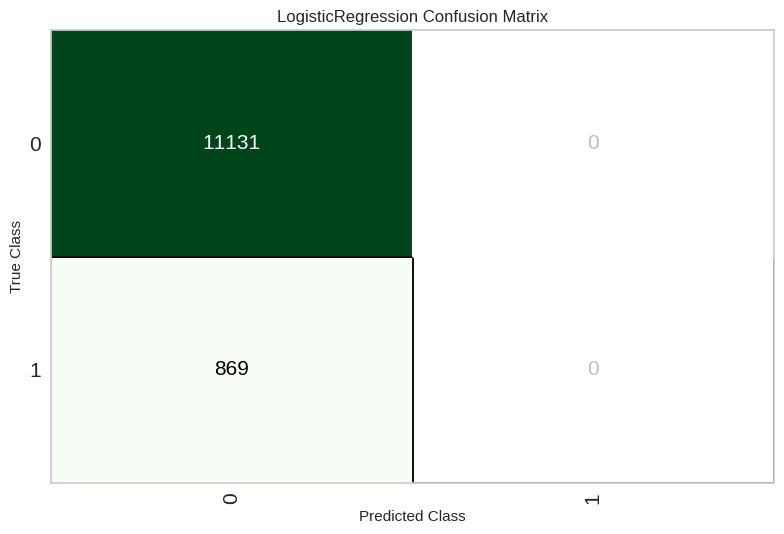

Model 2: RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=2694, solver='auto',
                tol=0.0001)


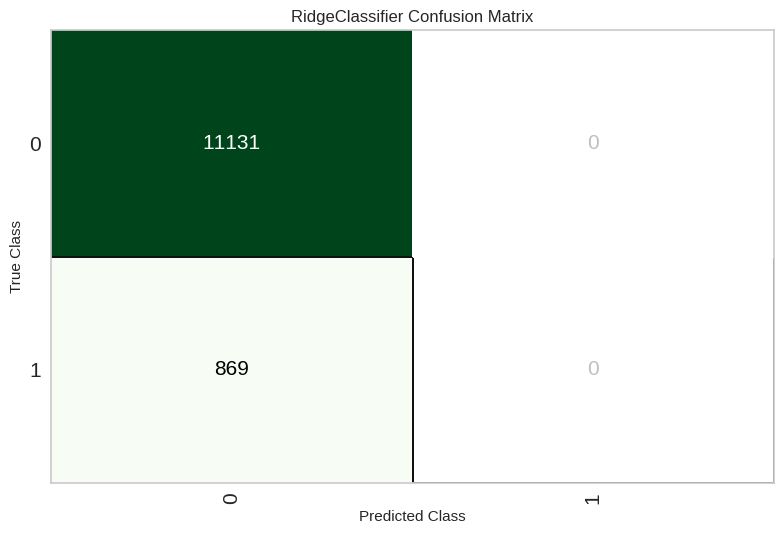

Model 3: DummyClassifier(constant=None, random_state=2694, strategy='prior')


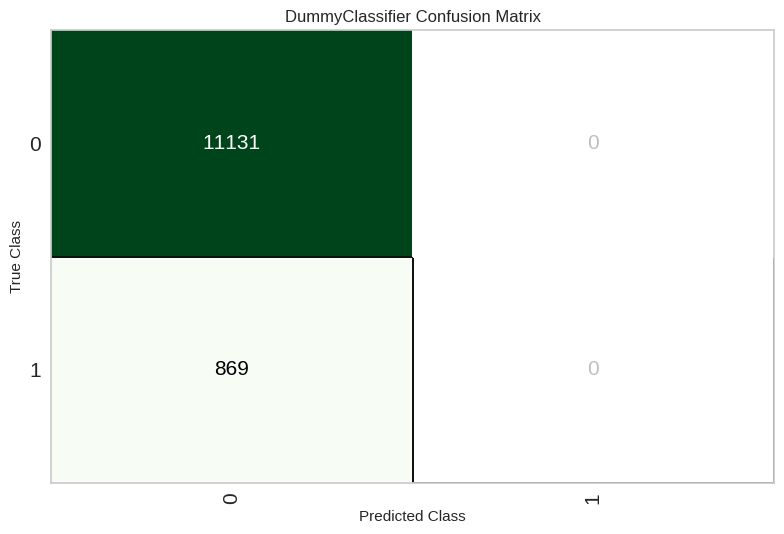

In [ ]:
for i in range(3):
  model = top_baseline_models_call_recipient[i]
  print(f"Model {i+1}: {model}")
  plot_model(model, plot='confusion_matrix', plot_kwargs = {'figure': {'dpi': 100}})

## Prediction

In [ ]:
pred = predict_model(baseline_models)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9276,0.6073,0.9276,0.8604,0.8927,0.0000,0.0000


In [ ]:
pred.head()

,age,job,marital,education,default,balance,housing,loan,y,prediction_label,prediction_score
14536,33,services,divorced,secondary,no,437,yes,no,no,no,0.9210
21374,35,housemaid,married,primary,no,0,no,no,no,no,0.9492
23810,35,technician,divorced,secondary,no,515,yes,yes,no,no,0.9404
30997,41,unemployed,married,primary,no,819,no,no,no,no,0.9260
27651,37,management,single,tertiary,no,2173,no,no,no,no,0.8709


# Resample

There is an overwhelming number of non-subscribers compared to the subscribers; there's a class imbalance.


Try resampling on the trained data

- undersampling
  - random undersampling: reduce the majority class so that it has similar distribution as the minority class

- oversampling: inflates the minority class so that it has a similar distribution as the majority class
  - smote: synthetitcally generate the samples
    - smote enn
    - smote tomek

## Random Undersampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

random_undersampler = RandomUnderSampler(random_state=seed)
X_train_call_recipient_rus, y_train_call_recipient_rus = random_undersampler.fit_resample(X_train_call_recipient, y_train_call_recipient)

In [ ]:
df_train_call_recipient_rus = pd.concat([X_train_call_recipient_rus, y_train_call_recipient_rus], axis=1)

setup(data = df_train_call_recipient_rus, target = 'y', session_id = seed, test_data = pd.concat([X_test_call_recipient, y_test_call_recipient], axis=1))

,Description,Value
0,Session id,2694
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(16054, 9)"
5,Transformed data shape,"(16054, 25)"
6,Transformed train set shape,"(4054, 25)"
7,Transformed test set shape,"(12000, 25)"
8,Numeric features,2
9,Categorical features,6


In [ ]:
call_recipient_rus_models = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.5804,0.6207,0.5804,0.5808,0.5798,0.1608,0.1612,0.7060
lr,Logistic Regression,0.5789,0.6048,0.5789,0.5794,0.5783,0.1578,0.1583,1.6200
ridge,Ridge Classifier,0.5787,0.6046,0.5787,0.5792,0.5780,0.1573,0.1578,0.1800
ada,Ada Boost Classifier,0.5787,0.6214,0.5787,0.5792,0.5779,0.1574,0.1578,0.3350
lda,Linear Discriminant Analysis,0.5787,0.6047,0.5787,0.5792,0.5780,0.1573,0.1578,0.1540
lightgbm,Light Gradient Boosting Machine,0.5723,0.6014,0.5723,0.5724,0.5721,0.1445,0.1446,0.3930
nb,Naive Bayes,0.5651,0.5892,0.5651,0.5654,0.5646,0.1302,0.1305,0.1500
rf,Random Forest Classifier,0.5565,0.5783,0.5565,0.5567,0.5561,0.1129,0.1132,0.8490
xgboost,Extreme Gradient Boosting,0.5486,0.5722,0.5486,0.5487,0.5484,0.0972,0.0973,0.2660
et,Extra Trees Classifier,0.5459,0.5639,0.5459,0.5460,0.5457,0.0917,0.0918,0.8740


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

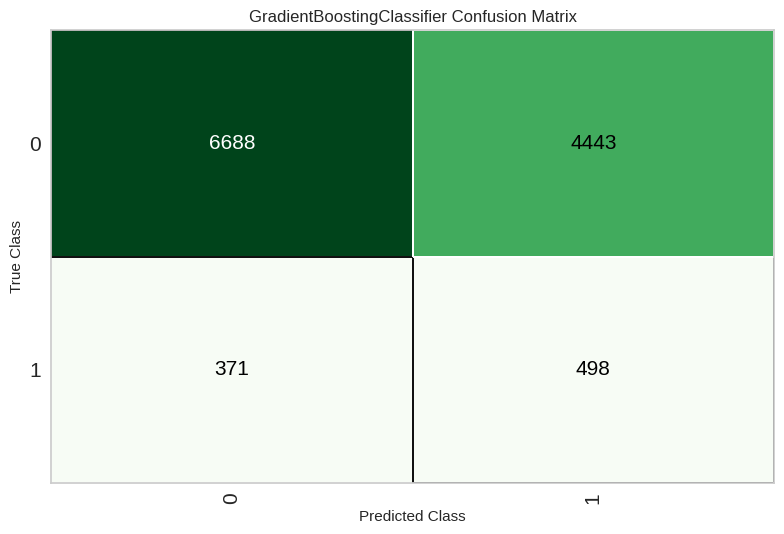

In [ ]:
plot_model(call_recipient_rus_models, plot='confusion_matrix')

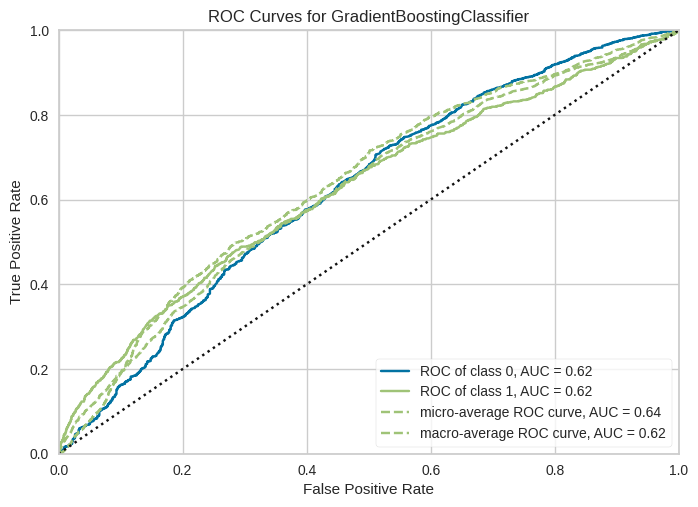

In [ ]:
plot_model(call_recipient_rus_models, plot='auc')

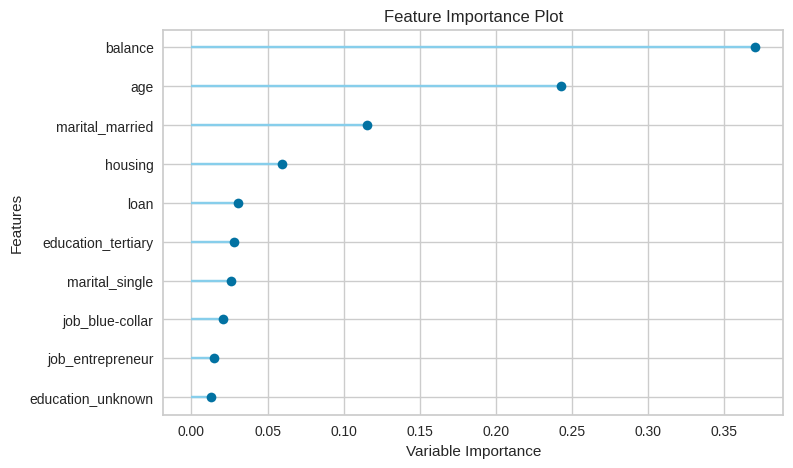

In [ ]:
plot_model(call_recipient_rus_models, plot='feature')

save the model

In [ ]:
save_model(rus_models, 'rus_model_call_target_customers')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=['age', 'balance'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strate...
                                             criterion='friedman_mse', init=None,
                                             learning_rate=0.1, loss='log_loss',
     

In [ ]:
import shutil

source_path = 'rus_model_call_target_customers.pkl'
destination_path = '/content/drive/My Drive/Apziva/rus_model_call_target_customers.pkl'

shutil.copy(source_path, destination_path)
print(f"File '{source_path}' successfully saved to '{destination_path}'")

File 'rus_model_call_target_customers.pkl' successfully saved to '/content/drive/My Drive/Apziva/rus_model_call_target_customers.pkl'


### Random undersampling with hyperopt

In [ ]:
tuned_call_recipient_rus_models = tune_model(call_recipient_rus_models, search_library = 'tune-sklearn', search_algorithm='hyperopt')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,07:17:35
Status,. . . . . . . . . . . . . . . . . .,Searching Hyperparameters
Estimator,. . . . . . . . . . . . . . . . . .,Gradient Boosting Classifier


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

2026-02-01 07:17:42,015	INFO worker.py:1642 -- Started a local Ray instance.
2026-02-01 07:17:46,867	INFO tune.py:228 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `tune.run(...)`.
2026-02-01 07:17:46,876	INFO tune.py:654 -- [output] This will use the new output engine with verbosity 1. To disable the new output and use the legacy output engine, set the environment variable RAY_AIR_NEW_OUTPUT=0. For more information, please see https://github.com/ray-project/ray/issues/36949


+-------------------------------------------------------------------+
| Configuration for experiment     _Trainable_2026-02-01_07-17-46   |
+-------------------------------------------------------------------+
| Search algorithm                 SearchGenerator                  |
| Scheduler                        FIFOScheduler                    |
| Number of trials                 10                               |
+-------------------------------------------------------------------+

View detailed results here: /root/ray_results/_Trainable_2026-02-01_07-17-46
To visualize your results with TensorBoard, run: `tensorboard --logdir ~/ray_results/_Trainable_2026-02-01_07-17-46`

Trial status: 1 PENDING
Current time: 2026-02-01 07:17:51. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/0 GPUs
+--------------------------------+
| Trial name            status   |
+--------------------------------+
| _Trainable_68195953   PENDING  |
+--------------------------------+

Trial _Traina

2026-02-01 07:20:59,198	WARNING experiment_state.py:311 -- The previous sync of the experiment directory to the cloud failed with the error: '/root/ray_results/_Trainable_2026-02-01_07-17-46' is not in the subpath of '~/ray_results/_Trainable_2026-02-01_07-17-46' OR one path is relative and the other is absolute.
Syncing will be retried.
2026-02-01 07:20:59,202	WARNING tune.py:1118 -- Trial Runner checkpointing failed: Uploading the experiment directory from the driver (local path: ~/ray_results/_Trainable_2026-02-01_07-17-46) to the the cloud (remote path: /root/ray_results/_Trainable_2026-02-01_07-17-46) failed. Please check the error message above.



Trial _Trainable_1da135a7 completed after 1 iterations at 2026-02-01 07:20:59. Total running time: 3min 7s
+----------------------------------------------+
| Trial _Trainable_1da135a7 result             |
+----------------------------------------------+
| checkpoint_dir_name                          |
| time_this_iter_s                     33.1606 |
| time_total_s                         33.1606 |
| training_iteration                         1 |
| average_test_score                   0.56535 |
| objective                            0.56535 |
| split0_test_score                    0.57143 |
| split1_test_score                    0.60099 |
| split2_test_score                    0.55419 |
| split3_test_score                    0.59852 |
| split4_test_score                    0.54815 |
| split5_test_score                    0.52099 |
| split6_test_score                    0.56543 |
| split7_test_score                    0.57037 |
| split8_test_score                    0.55802 |
| split9_t

ValueError: No experiment checkpoint file of form 'experiment_state-*.json' was found at: (local, /root/ray_results/_Trainable_2026-02-01_07-17-46)
Please check if you specified the correct experiment path, which should be a combination of the `storage_path` and `name` specified in your run.

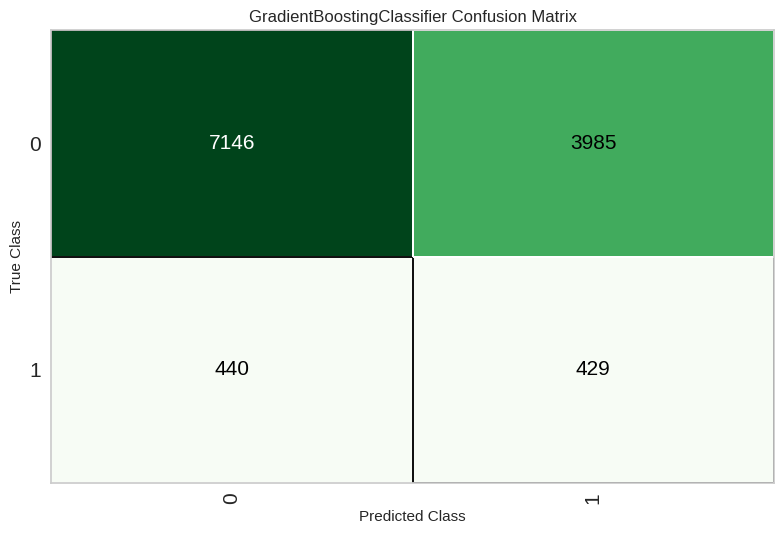

In [ ]:
plot_model(tuned_rus_models, plot='confusion_matrix')

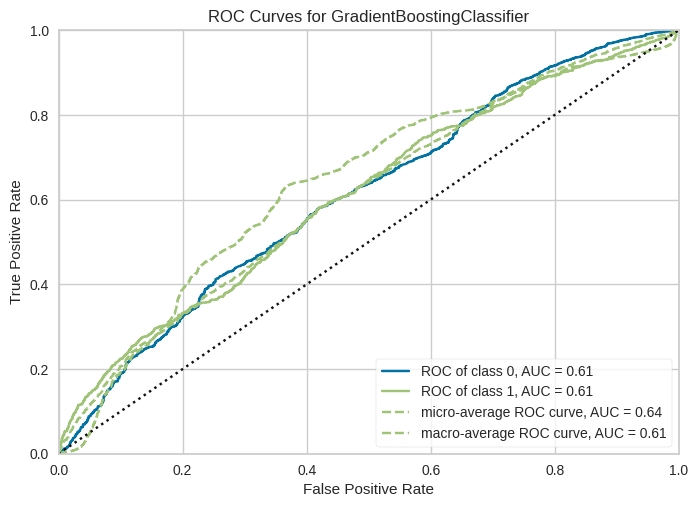

In [ ]:
plot_model(tuned_rus_models, plot='auc')

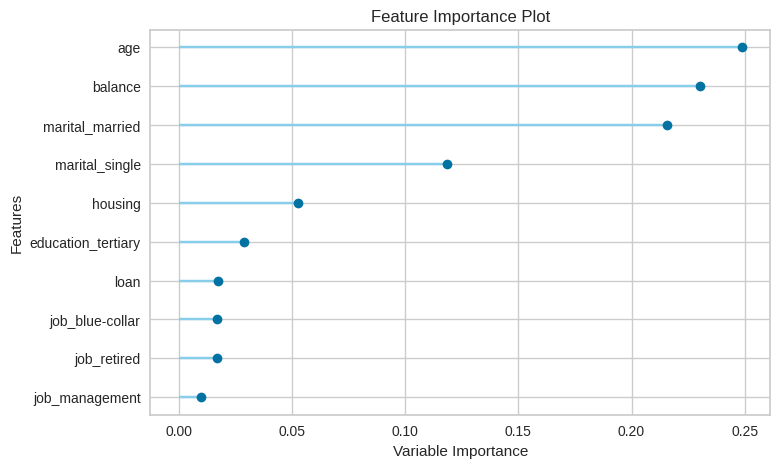

In [ ]:
plot_model(tuned_rus_models, plot='feature')

## Oversampling - SMOTE ENN

In [ ]:
import pandas as pd

# Identify categorical columns in the original X_train
categorical_cols = X_train_call_recipient.select_dtypes(include='object').columns

# Perform one-hot encoding on the categorical columns of X_train, convert boolean to int
X_train_call_recipient_encoded = pd.get_dummies(X_train_call_recipient, columns=categorical_cols, drop_first=True).astype(int)

# Perform one-hot encoding on the categorical columns of X_test, convert boolean to int
X_test_call_recipient_encoded = pd.get_dummies(X_test_call_recipient, columns=categorical_cols, drop_first=True).astype(int)

# Align columns - crucial for consistency if train/test have different category occurrences
train_cols = X_train_call_recipient_encoded.columns
test_cols = X_test_call_recipient_encoded.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_call_recipient_encoded[c] = 0 # Fill with 0 for missing dummy variables

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_call_recipient_encoded[c] = 0 # Fill with 0 for missing dummy variables

X_test_call_recipient_encoded = X_test_call_recipient_encoded[train_cols] # Ensure order and presence of all train columns

# Display the head of the encoded DataFrame to show the transformation
print("Original X_train_call_recipient head:")
display(X_train_call_recipient.head())
print("\nEncoded X_train_call_recipient head (for SMOTEENN - integer dummified):")
display(X_train_call_recipient_encoded.head())
print("\nEncoded X_test head (for SMOTEENN - integer dummified):")
display(X_test_call_recipient_encoded.head())

Original X_train_call_recipient head:


,age,balance,default,education,housing,job,loan,marital
3560,57,1,no,primary,no,admin,no,divorced
27709,40,0,yes,primary,yes,blue-collar,no,divorced
7891,42,1958,no,secondary,yes,blue-collar,no,married
16166,36,286,no,secondary,yes,admin,no,married
30776,28,1137,no,secondary,no,blue-collar,no,married



Encoded X_train_call_recipient head (for SMOTEENN - integer dummified):


,age,balance,default_yes,education_secondary,education_tertiary,education_unknown,housing_yes,job_blue-collar,job_entrepreneur,job_housemaid,...,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,loan_yes,marital_married,marital_single
3560,57,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27709,40,0,1,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7891,42,1958,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,1,0
16166,36,286,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
30776,28,1137,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0



Encoded X_test head (for SMOTEENN - integer dummified):


,age,balance,default_yes,education_secondary,education_tertiary,education_unknown,housing_yes,job_blue-collar,job_entrepreneur,job_housemaid,...,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,loan_yes,marital_married,marital_single
14536,33,437,0,1,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
21374,35,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
23810,35,515,0,1,0,0,1,0,0,0,...,0,0,0,0,1,0,0,1,0,0
30997,41,819,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
27651,37,2173,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
from imblearn.combine import SMOTEENN

# Apply SMOTEENN to the one-hot encoded X_train and y_train
smote_enn = SMOTEENN(random_state=seed)
X_train_smote_enn_call_recipient, y_train_smote_enn_call_recipient = smote_enn.fit_resample(X_train_call_recipient_encoded, y_train_call_recipient)

In [ ]:
df_train_call_recipient_smote_enn = pd.concat([X_train_smote_enn_call_recipient, y_train_smote_enn_call_recipient], axis=1)

df_test_call_recipient_smote_enn = pd.concat([X_test_call_recipient_encoded, y_test_call_recipient], axis=1)

# Get all column names from df_train_smote_enn that are now numerical features
# All columns except the target 'y' should now be numerical (0s, 1s, or original numerical)
all_feature_columns_call_recipient_smote_enn = [col for col in df_train_call_recipient_smote_enn.columns if col != 'y']

setup(data = df_train_call_recipient_smote_enn,
      target = 'y',
      session_id = seed,
      test_data = df_test_call_recipient_smote_enn,
      index=False,
      numeric_features=all_feature_columns_call_recipient_smote_enn,
      categorical_features=[] # Explicitly tell PyCaret no string-based categorical features are left
     )

,Description,Value
0,Session id,2694
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(44792, 22)"
5,Transformed data shape,"(44792, 22)"
6,Transformed train set shape,"(32792, 22)"
7,Transformed test set shape,"(12000, 22)"
8,Numeric features,21
9,Preprocess,True


In [ ]:
call_recipient_smote_enn_models = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.9576,0.9891,0.9576,0.9585,0.9574,0.9104,0.9118,1.6550
rf,Random Forest Classifier,0.9344,0.9793,0.9344,0.9446,0.9338,0.8679,0.8756,3.4410
et,Extra Trees Classifier,0.9236,0.9765,0.9236,0.9344,0.9228,0.8453,0.8536,3.1780
xgboost,Extreme Gradient Boosting,0.9213,0.9725,0.9213,0.9318,0.9204,0.8415,0.8489,0.4910
dt,Decision Tree Classifier,0.9209,0.9138,0.9209,0.9299,0.9202,0.8373,0.8452,0.2490
lightgbm,Light Gradient Boosting Machine,0.9041,0.9645,0.9041,0.9145,0.9031,0.8068,0.8134,1.5130
gbc,Gradient Boosting Classifier,0.8696,0.9430,0.8696,0.8786,0.8684,0.7331,0.7393,2.7480
ada,Ada Boost Classifier,0.8640,0.9397,0.8640,0.8738,0.8623,0.7212,0.7282,1.0880
ridge,Ridge Classifier,0.8622,0.9333,0.8622,0.8754,0.8607,0.7242,0.7310,0.2870
lda,Linear Discriminant Analysis,0.8616,0.9333,0.8616,0.8749,0.8601,0.7230,0.7299,0.3710


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

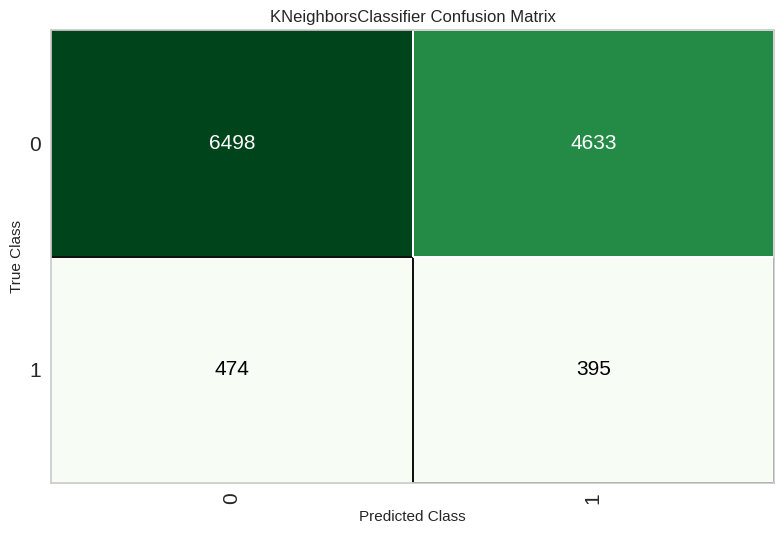

In [ ]:
plot_model(call_recipient_smote_enn_models, plot='confusion_matrix')

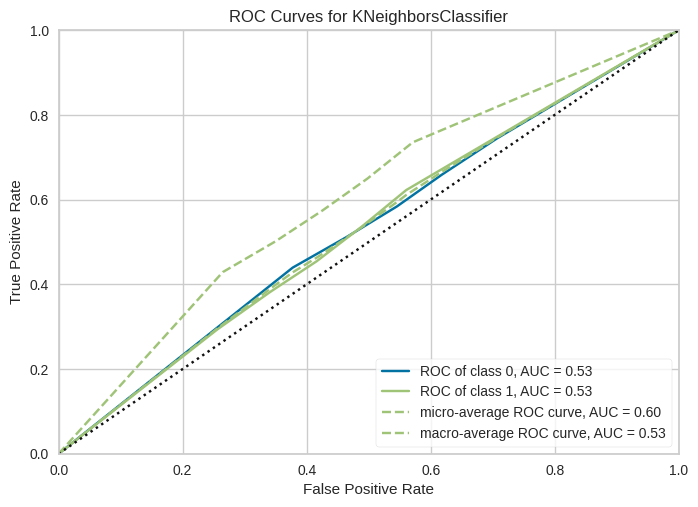

In [ ]:
plot_model(call_recipient_smote_enn_models, plot='auc')

### Oversampling - Smote ENN with hyperopt

In [ ]:
tuned_call_recipient_smote_enn_models = tune_model(call_recipient_smote_enn_models, search_library = 'tune-sklearn', search_algorithm='hyperopt')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,07:39:59
Status,. . . . . . . . . . . . . . . . . .,Searching Hyperparameters
Estimator,. . . . . . . . . . . . . . . . . .,K Neighbors Classifier


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

2026-02-01 07:40:00,259	INFO tune.py:654 -- [output] This will use the new output engine with verbosity 1. To disable the new output and use the legacy output engine, set the environment variable RAY_AIR_NEW_OUTPUT=0. For more information, please see https://github.com/ray-project/ray/issues/36949


+-------------------------------------------------------------------+
| Configuration for experiment     _Trainable_2026-02-01_07-40-00   |
+-------------------------------------------------------------------+
| Search algorithm                 SearchGenerator                  |
| Scheduler                        FIFOScheduler                    |
| Number of trials                 10                               |
+-------------------------------------------------------------------+

View detailed results here: /root/ray_results/_Trainable_2026-02-01_07-40-00
To visualize your results with TensorBoard, run: `tensorboard --logdir ~/ray_results/_Trainable_2026-02-01_07-40-00`

Trial status: 1 PENDING
Current time: 2026-02-01 07:40:00. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/0 GPUs
+--------------------------------+
| Trial name            status   |
+--------------------------------+
| _Trainable_2b52c636   PENDING  |
+--------------------------------+

Trial _Traina

2026-02-01 07:44:38,067	WARNING experiment_state.py:311 -- The previous sync of the experiment directory to the cloud failed with the error: '/root/ray_results/_Trainable_2026-02-01_07-40-00' is not in the subpath of '~/ray_results/_Trainable_2026-02-01_07-40-00' OR one path is relative and the other is absolute.
Syncing will be retried.
2026-02-01 07:44:38,071	WARNING tune.py:1118 -- Trial Runner checkpointing failed: Uploading the experiment directory from the driver (local path: ~/ray_results/_Trainable_2026-02-01_07-40-00) to the the cloud (remote path: /root/ray_results/_Trainable_2026-02-01_07-40-00) failed. Please check the error message above.



Trial _Trainable_17b7930b completed after 1 iterations at 2026-02-01 07:44:38. Total running time: 4min 37s
+----------------------------------------------+
| Trial _Trainable_17b7930b result             |
+----------------------------------------------+
| checkpoint_dir_name                          |
| time_this_iter_s                     54.5417 |
| time_total_s                         54.5417 |
| training_iteration                         1 |
| average_test_score                   0.79888 |
| objective                            0.79888 |
| split0_test_score                    0.77622 |
| split1_test_score                    0.79787 |
| split2_test_score                    0.80787 |
| split3_test_score                    0.79811 |
| split4_test_score                    0.80573 |
| split5_test_score                    0.79933 |
| split6_test_score                     0.7914 |
| split7_test_score                    0.79872 |
| split8_test_score                    0.80146 |
| split9_

ValueError: No experiment checkpoint file of form 'experiment_state-*.json' was found at: (local, /root/ray_results/_Trainable_2026-02-01_07-40-00)
Please check if you specified the correct experiment path, which should be a combination of the `storage_path` and `name` specified in your run.

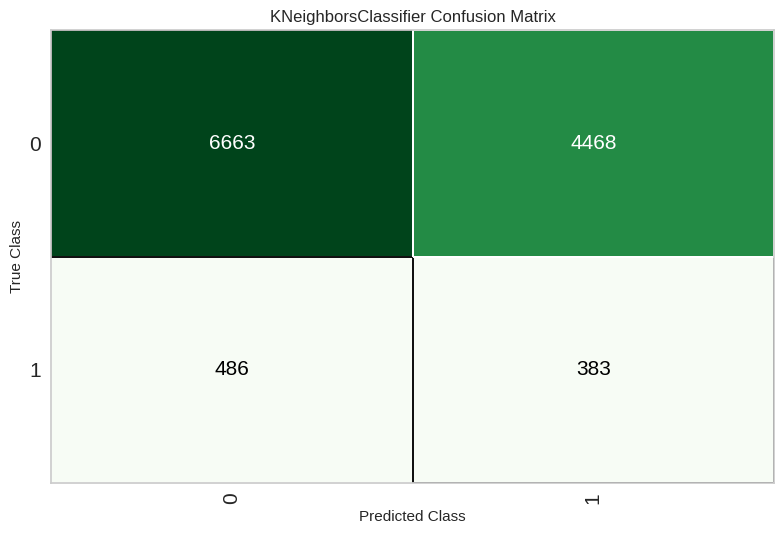

In [ ]:
plot_model(tuned_smote_enn_models, plot='confusion_matrix')

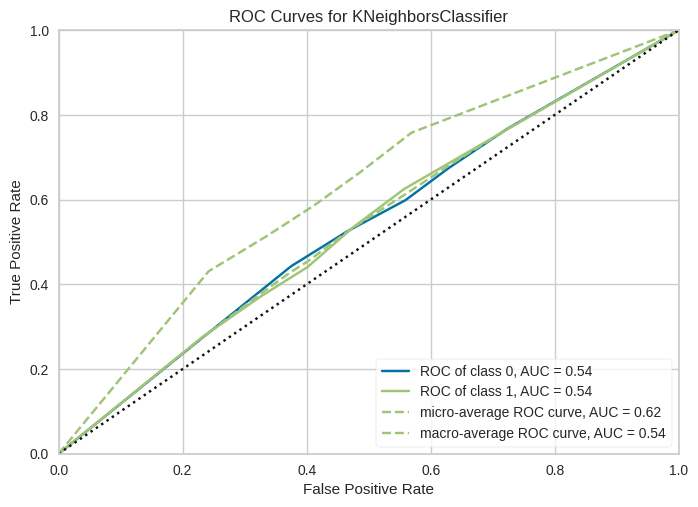

In [ ]:
plot_model(tuned_smote_enn_models, plot='auc')

## Oversampling - SMOTE Tomek

In [ ]:
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(random_state=seed)
X_train_call_recipient_smote_tomek, y_train_call_recipient_smote_tomek = smote_tomek.fit_resample(X_train_call_recipient_encoded, y_train_call_recipient)

In [ ]:
df_train_call_recipient_smote_tomek = pd.concat([X_train_call_recipient_smote_tomek, y_train_call_recipient_smote_tomek], axis=1)

df_test_call_recipient_smote_tomek = pd.concat([X_test_call_recipient_encoded, y_test_call_recipient], axis=1)

# Get all column names from df_train_smote_enn that are now numerical features
# All columns except the target 'y' should now be numerical (0s, 1s, or original numerical)
all_feature_columns_call_recipient_smote_tomek = [col for col in df_train_call_recipient_smote_tomek.columns if col != 'y']

setup(data = df_train_call_recipient_smote_tomek,
      target = 'y',
      session_id = seed,
      test_data = df_test_call_recipient_smote_tomek,
      index=False,
      numeric_features=all_feature_columns_call_recipient_smote_tomek,
      categorical_features=[] # Explicitly tell PyCaret no string-based categorical features are left
     )

,Description,Value
0,Session id,2694
1,Target,y
2,Target type,Binary
3,Target mapping,"no: 0, yes: 1"
4,Original data shape,"(61476, 22)"
5,Transformed data shape,"(61476, 22)"
6,Transformed train set shape,"(49476, 22)"
7,Transformed test set shape,"(12000, 22)"
8,Numeric features,21
9,Preprocess,True


In [ ]:
call_recipient_smote_tomek_models = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9253,0.9711,0.9253,0.9322,0.9237,0.8506,0.8572,5.5460
et,Extra Trees Classifier,0.9139,0.9633,0.9139,0.9210,0.9121,0.8278,0.8345,5.6990
dt,Decision Tree Classifier,0.9127,0.9156,0.9127,0.9203,0.9113,0.8253,0.8328,0.6980
xgboost,Extreme Gradient Boosting,0.9032,0.9594,0.9032,0.9101,0.9007,0.8065,0.8128,0.7360
lightgbm,Light Gradient Boosting Machine,0.8883,0.9521,0.8883,0.8955,0.8850,0.7766,0.7831,2.1540
gbc,Gradient Boosting Classifier,0.8665,0.9317,0.8665,0.8730,0.8631,0.7331,0.7389,4.6390
ada,Ada Boost Classifier,0.8626,0.9297,0.8626,0.8681,0.8596,0.7252,0.7302,1.6350
lr,Logistic Regression,0.8619,0.9275,0.8619,0.8674,0.8588,0.7239,0.7288,6.5770
ridge,Ridge Classifier,0.8569,0.9248,0.8569,0.8626,0.8536,0.7138,0.7190,0.3980
lda,Linear Discriminant Analysis,0.8568,0.9247,0.8568,0.8625,0.8535,0.7136,0.7188,0.3450


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

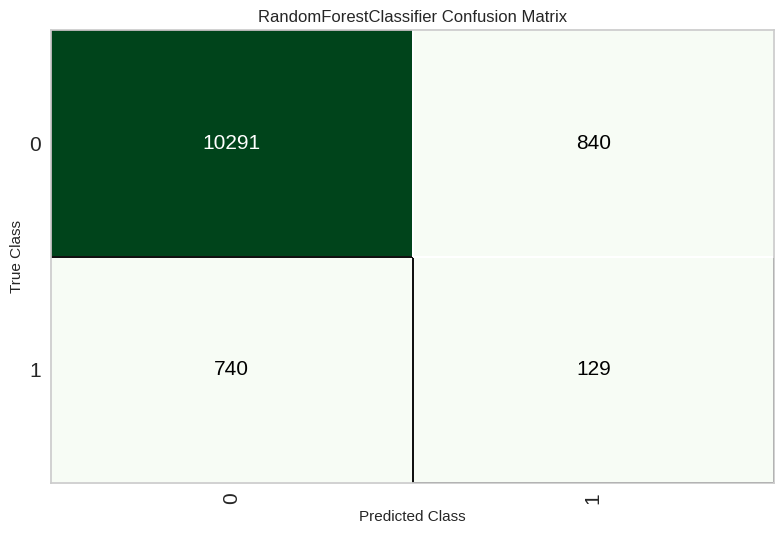

In [ ]:
plot_model(call_recipient_smote_tomek_models, plot='confusion_matrix')

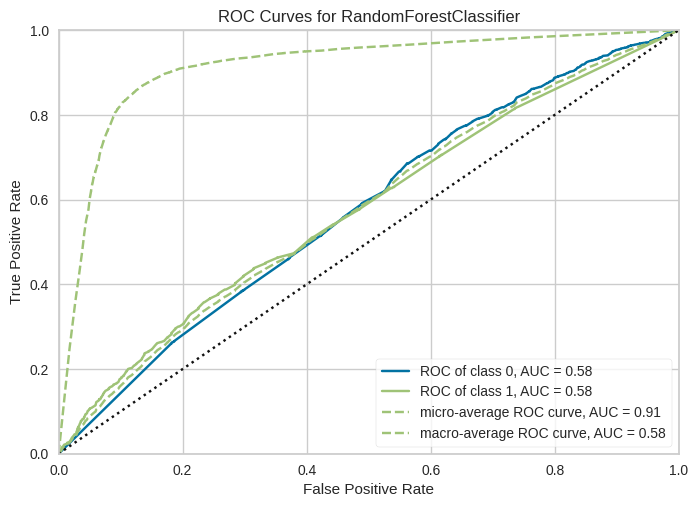

In [ ]:
plot_model(call_recipient_smote_tomek_models, plot='auc')

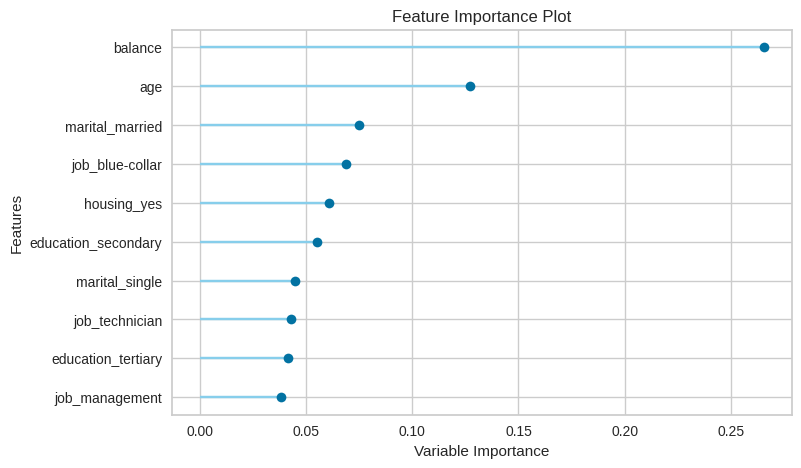

In [ ]:
plot_model(call_recipient_smote_tomek_models, plot='feature')

### Oversampling - SMOTE Tomek with hyperopt

In [ ]:
tuned_smote_tomek_models = tune_model(smote_tomek_models, search_library = 'tune-sklearn', search_algorithm='hyperopt')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6433,0.7235,0.6433,0.6822,0.6232,0.2866,0.3231
1,0.8759,0.9490,0.8759,0.8763,0.8759,0.7518,0.7522
2,0.8777,0.9528,0.8777,0.8778,0.8777,0.7555,0.7555
3,0.8848,0.9546,0.8848,0.8849,0.8848,0.7696,0.7697
4,0.8674,0.9507,0.8674,0.8677,0.8674,0.7348,0.7351
5,0.8684,0.9488,0.8684,0.8687,0.8684,0.7369,0.7371
6,0.8682,0.9455,0.8682,0.8686,0.8682,0.7364,0.7368
7,0.8714,0.9512,0.8714,0.8714,0.8714,0.7429,0.7429
8,0.8759,0.9543,0.8759,0.8767,0.8758,0.7518,0.7525


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

2026-01-29 14:59:41,910	INFO tune.py:654 -- [output] This will use the new output engine with verbosity 1. To disable the new output and use the legacy output engine, set the environment variable RAY_AIR_NEW_OUTPUT=0. For more information, please see https://github.com/ray-project/ray/issues/36949


+-------------------------------------------------------------------+
| Configuration for experiment     _Trainable_2026-01-29_14-59-41   |
+-------------------------------------------------------------------+
| Search algorithm                 SearchGenerator                  |
| Scheduler                        FIFOScheduler                    |
| Number of trials                 10                               |
+-------------------------------------------------------------------+

View detailed results here: /root/ray_results/_Trainable_2026-01-29_14-59-41
To visualize your results with TensorBoard, run: `tensorboard --logdir /root/ray_results/_Trainable_2026-01-29_14-59-41`

Trial status: 1 PENDING
Current time: 2026-01-29 14:59:42. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/0 GPUs
+--------------------------------+
| Trial name            status   |
+--------------------------------+
| _Trainable_cd6f0942   PENDING  |
+--------------------------------+

Trial _Tr

(_Trainable pid=34333) Trainable.setup took 10.593 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.



Trial _Trainable_26a7c432 started with configuration:
+----------------------------------------------------------------+
| Trial _Trainable_26a7c432 config                               |
+----------------------------------------------------------------+
| actual_estimator__bootstrap                              False |
| actual_estimator__criterion                               gini |
| actual_estimator__max_depth                                  1 |
| actual_estimator__max_features                         0.55145 |
| actual_estimator__min_impurity_decrease                 0.0001 |
| actual_estimator__min_samples_leaf                           5 |
| actual_estimator__min_samples_split                          5 |
| actual_estimator__n_estimators                             234 |
| cv                                        ...e, shuffle=False) |
| early_stop_type                           ...ing.NO_EARLY_STOP |
| early_stopping                                           False |
| error

Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


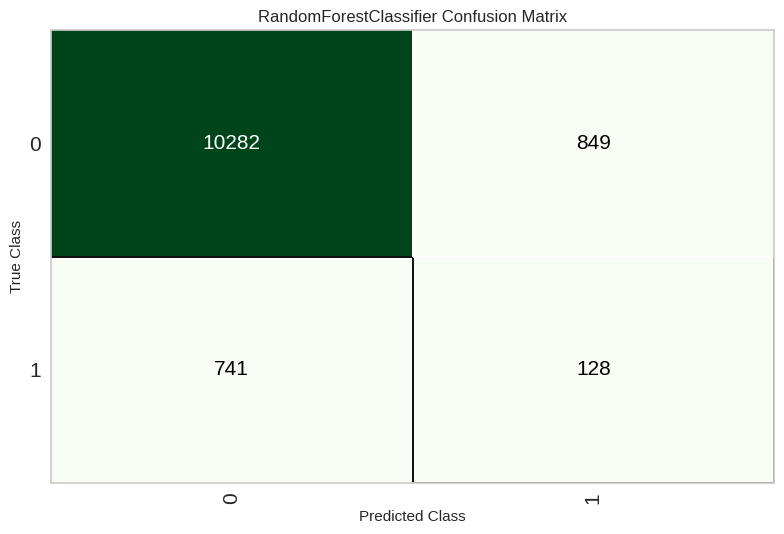

In [ ]:
plot_model(tuned_smote_tomek_models, plot='confusion_matrix')

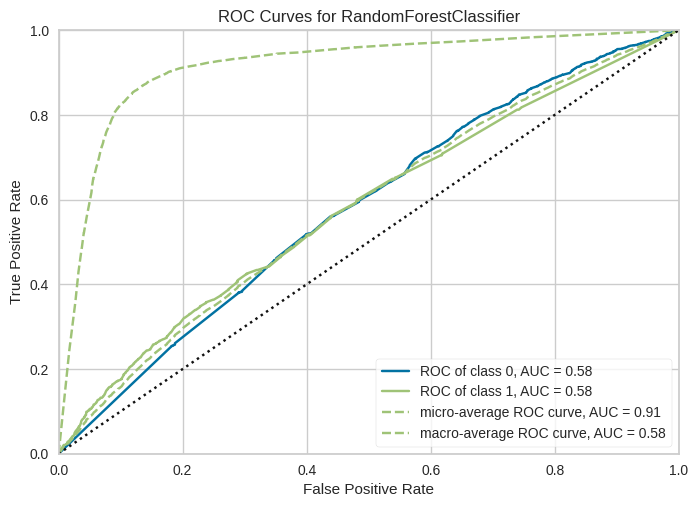

In [ ]:
plot_model(tuned_smote_tomek_models, plot='auc')

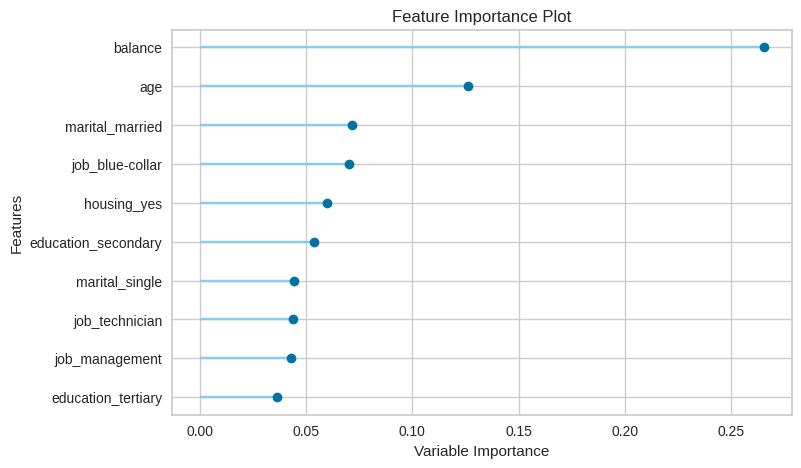

In [ ]:
plot_model(tuned_smote_tomek_models, plot='feature')

### Oversampling - SMOTE Tomek with class_weight

In [ ]:
from pycaret.classification import create_model
from sklearn.ensemble import RandomForestClassifier

# Example of creating a RandomForestClassifier with class_weight using PyCaret
# This would be done after your PyCaret setup for the SMOTETomek data

# You can choose 'balanced' or 'balanced_subsample' or a custom dictionary
# For example, using 'balanced':
rf_model_with_class_weight = create_model(
    'rf', # Random Forest classifier
    cross_validation = False, # Set to False if you just want to create the model without cross-validation output
    class_weight='balanced' # Apply balanced class weights
)

print("RandomForestClassifier created with class_weight='balanced':")
print(rf_model_with_class_weight)

# If you were tuning, you could pass it similarly:
# tuned_rf_model = tune_model(rf_model_with_class_weight, search_library = 'tune-sklearn', search_algorithm='hyperopt')
# Note: tune_model automatically optimizes parameters, and class_weight is a hyperparameter itself.
# If you want to tune other hyperparameters *while* keeping class_weight, you might need a custom grid or specific tuning strategies.

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Test,0.8683,0.5775,0.8683,0.8750,0.8716,0.0693,0.0694


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

RandomForestClassifier created with class_weight='balanced':
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight='balanced',
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=2694, verbose=0,
                       warm_start=False)


Confusion Matrix for RandomForestClassifier with class_weight='balanced':


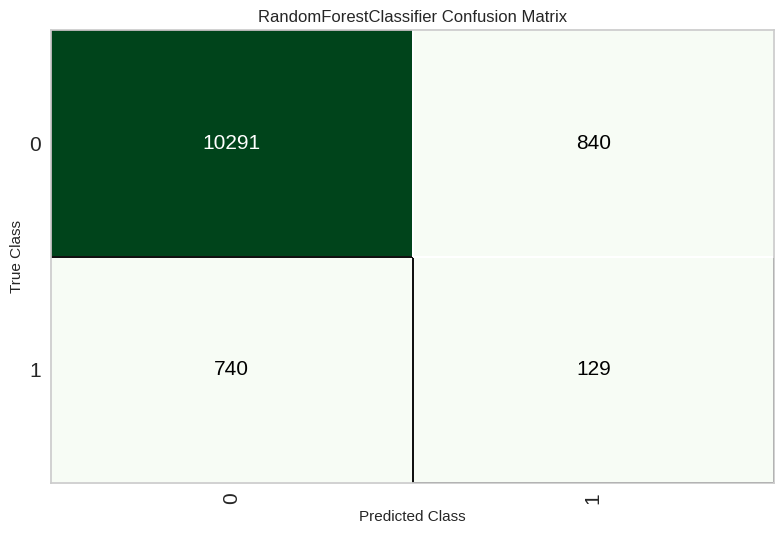

AUC Plot for RandomForestClassifier with class_weight='balanced':


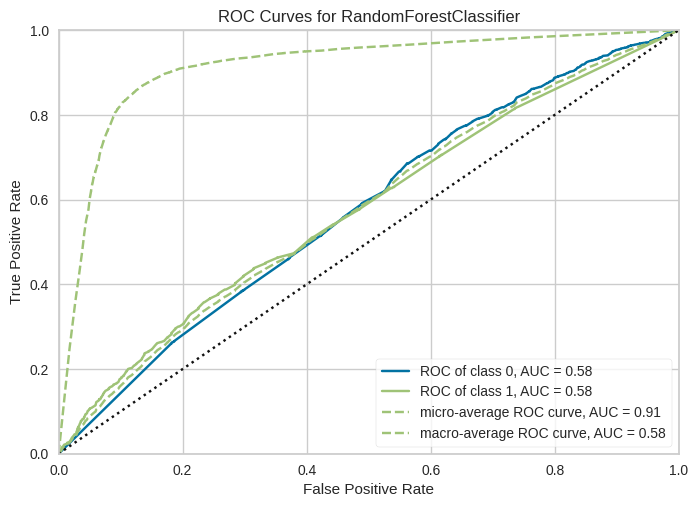

Feature Importance Plot for RandomForestClassifier with class_weight='balanced':


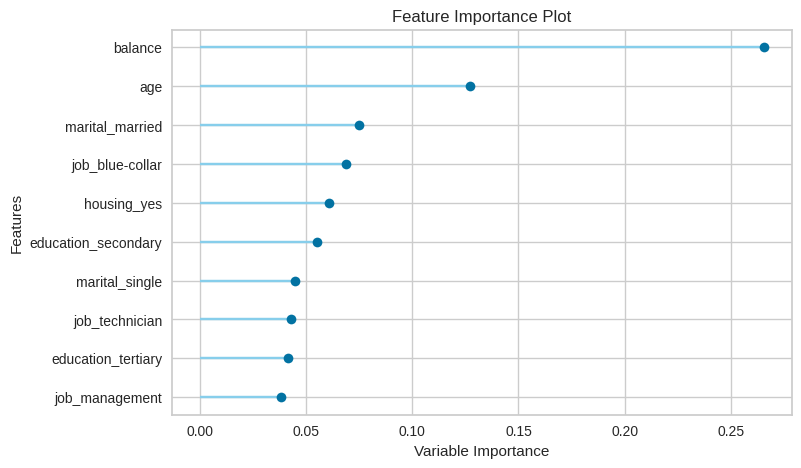

In [ ]:
print("Confusion Matrix for RandomForestClassifier with class_weight='balanced':")
plot_model(rf_model_with_class_weight, plot='confusion_matrix', plot_kwargs = {'figure': {'dpi': 100}})

print("AUC Plot for RandomForestClassifier with class_weight='balanced':")
plot_model(rf_model_with_class_weight, plot='auc')

print("Feature Importance Plot for RandomForestClassifier with class_weight='balanced':")
plot_model(rf_model_with_class_weight, plot='feature')